In [1]:
# Data Analysis libraries
import numpy as np # type: ignore
import pandas as pd # type: ignore

In [2]:
# Data Visualization libraries
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore

In [3]:
# Configuration
%matplotlib inline
sns.set_style("whitegrid")

In [4]:
# Avoid warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load dataset
path = r'C:\Users\NoteBook\Desktop\traffic_ai_system\dataset\US_Accidents_500k.csv'
df = pd.read_csv(path)

In [6]:
# Top five rows
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,6/12/2019 10:10,6/12/2019 10:55,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,37:14.0,56:53.0,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,13:00.0,22:45.0,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2/21/2022 17:43,2/21/2022 19:43,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,12/4/2020 1:46,12/4/2020 4:13,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


In [7]:
# Number of rows and columns
number_of_rows , number_of_columns = df.shape

In [8]:
print(f'Our dataset has {number_of_rows} rows')
print(f'Our dataset has {number_of_columns} columns')

Our dataset has 500000 rows
Our dataset has 46 columns


In [9]:
# Let's see the list of all columns
print(df.columns)

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')


In [10]:
# Convert time columns to datetime
df["Start_Time"] = pd.to_datetime(df["Start_Time"],errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"],errors="coerce")

In [11]:
# Check information about them
df[["Start_Time", "End_Time"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Start_Time  451837 non-null  datetime64[us]
 1   End_Time    451837 non-null  datetime64[us]
dtypes: datetime64[us](2)
memory usage: 7.6 MB


In [12]:
# Check for missing values
print(df[["Start_Time", "End_Time"]].isnull().sum())

Start_Time    48163
End_Time      48163
dtype: int64


In [13]:
# Calculate duration in minutes
df["Duration"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60

In [14]:
# Top 5 rows of Duration column
df["Duration"].head()

0     45.0
1      NaN
2      NaN
3    120.0
4    147.0
Name: Duration, dtype: float64

In [15]:
# Let's see statistics
df["Duration"].describe()

count    4.518370e+05
mean     4.016755e+02
std      1.294558e+04
min      3.000000e+00
25%      3.000000e+01
50%      6.300000e+01
75%      1.230000e+02
max      2.236405e+06
Name: Duration, dtype: float64

In [16]:
# Number of missing values
print(df["Duration"].isnull().sum())

48163


In [17]:
# Remove rows with missing duration
df = df.dropna(subset=["Duration"]).copy()

In [18]:
print("Negative durations:", (df["Duration"] < 0).sum())
print("Zero durations:", (df["Duration"] == 0).sum())

Negative durations: 0
Zero durations: 0


In [19]:
df["Duration"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

0.900     250.000
0.950     360.000
0.990     776.000
0.995    1046.820
0.999    4920.656
Name: Duration, dtype: float64

In [20]:
# Remove extreme outliers (keep 99% of data)
upper_limit = df["Duration"].quantile(0.99)

df = df[df["Duration"] <= upper_limit].copy()

df.reset_index(drop=True, inplace=True)

In [21]:
print(df.shape)

df["Duration"].describe()

(447332, 47)


count    447332.000000
mean        101.045289
std         105.409166
min           3.000000
25%          30.000000
50%          62.000000
75%         121.000000
max         776.000000
Name: Duration, dtype: float64

In [22]:
# Time-based features
df["Hour"] = df["Start_Time"].dt.hour
df["Month"] = df["Start_Time"].dt.month
df["Weekday"] = df["Start_Time"].dt.dayofweek
df["Year"] = df["Start_Time"].dt.year
df["Day"] = df["Start_Time"].dt.day
df["Is_Weekend"] = (df["Weekday"] >= 5).astype(int)

In [23]:
df[["Start_Time", "Hour", "Month", "Weekday", "Year", "Day", "Is_Weekend"]].head()

,Start_Time,Hour,Month,Weekday,Year,Day,Is_Weekend
0,2019-06-12 10:10:00,10,6,2,2019,12,0
1,2022-02-21 17:43:00,17,2,0,2022,21,0
2,2020-12-04 01:46:00,1,12,4,2020,4,0
3,2021-03-29 07:03:00,7,3,0,2021,29,0
4,2020-01-14 16:49:00,16,1,1,2020,14,0


In [24]:
numeric_features = [
    "Distance(mi)","Temperature(F)","Humidity(%)","Severity","Visibility(mi)",
    "Wind_Speed(mph)","Hour","Month","Weekday","Year","Day","Pressure(in)","Precipitation(in)"
]

binary_features = [
    "Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway",
    "Roundabout","Station","Stop","Traffic_Calming","Traffic_Signal","Is_Weekend"
]

categorical_features = [
    "Weather_Condition","State","Sunrise_Sunset"
]

In [25]:
selected_columns = [
    "Distance(mi)","Temperature(F)","Humidity(%)","Severity","Visibility(mi)","Wind_Speed(mph)",
    "Hour","Month","Weekday","Amenity","Bump","Crossing","Give_Way","Junction","No_Exit",
    "Railway","Roundabout","Station","Stop","Traffic_Calming","Traffic_Signal","Weather_Condition",
    "State","Sunrise_Sunset","Pressure(in)","Precipitation(in)","Is_Weekend","Day","Year"]


df[selected_columns].isnull().sum()

Distance(mi)              0
Temperature(F)         9219
Humidity(%)            9815
Severity                  0
Visibility(mi)         9974
Wind_Speed(mph)       35444
Hour                      0
Month                     0
Weekday                   0
Amenity                   0
Bump                      0
Crossing                  0
Give_Way                  0
Junction                  0
No_Exit                   0
Railway                   0
Roundabout                0
Station                   0
Stop                      0
Traffic_Calming           0
Traffic_Signal            0
Weather_Condition      9833
State                     0
Sunrise_Sunset         1089
Pressure(in)           7865
Precipitation(in)    140454
Is_Weekend                0
Day                       0
Year                      0
dtype: int64

In [26]:
numeric_columns = [
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [27]:
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")
df["Sunrise_Sunset"] = df["Sunrise_Sunset"].fillna("Unknown")

In [28]:
df["Pressure(in)"] = df["Pressure(in)"].fillna(
    df["Pressure(in)"].median()
)

df["Precipitation(in)"] = df["Precipitation(in)"].fillna(
    0
)

In [29]:
df[selected_columns].isnull().sum()

Distance(mi)         0
Temperature(F)       0
Humidity(%)          0
Severity             0
Visibility(mi)       0
Wind_Speed(mph)      0
Hour                 0
Month                0
Weekday              0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Weather_Condition    0
State                0
Sunrise_Sunset       0
Pressure(in)         0
Precipitation(in)    0
Is_Weekend           0
Day                  0
Year                 0
dtype: int64

In [30]:
print("Numeric Features:", len(numeric_features))
print("Binary Features:", len(binary_features))
print("Categorical Features:", len(categorical_features))

Numeric Features: 13
Binary Features: 13
Categorical Features: 3


In [31]:
# Features
X = df[
    numeric_features +
    binary_features +
    categorical_features
]

# Target
y = df["Duration"]

In [32]:
from sklearn.model_selection import train_test_split # type: ignore
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [33]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(357865, 29)
(89467, 29)
(357865,)
(89467,)


In [34]:
# Encoding Categorical Features
from sklearn.compose import ColumnTransformer # type: ignore
from sklearn.preprocessing import OneHotEncoder # type: ignore

preprocessor = ColumnTransformer(
    transformers=[
        (
            "weather",
            OneHotEncoder(handle_unknown="ignore",sparse_output=True),
            categorical_features
        )
    ],
    remainder="passthrough"
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [35]:
print("Train Shape:", X_train_processed.shape)
print("Test Shape:", X_test_processed.shape)

Train Shape: (357865, 180)
Test Shape: (89467, 180)


#### Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression # type: ignore
from sklearn.metrics import ( # type: ignore
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [37]:
linear_model = LinearRegression()     
print("Training Linear Regression...")
linear_model.fit(X_train_processed,y_train)
print("Training Complete!")

Training Linear Regression...
Training Complete!


In [38]:
# Prediction on Test Set
y_pred_linear = linear_model.predict(X_test_processed)

In [39]:
# Linear Model Evaluation
mae = mean_absolute_error(y_test,y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_linear))
r2 = r2_score(y_test,y_pred_linear)

In [40]:
print("LINEAR REGRESSION RESULTS")
print("=" * 40)

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R²   : {r2:.4f}")

LINEAR REGRESSION RESULTS
MAE  : 67.44 minutes
RMSE : 102.07 minutes
R²   : 0.0575


In [41]:
comparison = X_test.copy()

comparison["Actual Duration"] = y_test.values
comparison["Predicted Duration"] = y_pred_linear

comparison[
    [
        "Actual Duration",
        "Predicted Duration"
    ]
].head(10)

,Actual Duration,Predicted Duration
132772,75.0,113.833104
238382,45.0,99.006053
368730,60.0,101.227988
253227,64.0,72.304069
197038,141.0,99.172691
287828,90.0,129.375520
330152,129.0,93.052291
364955,30.0,60.717438
401108,60.0,166.525665
221987,32.0,97.964544


#### XGBoost Regressor

In [42]:
import xgboost as xgb # type: ignore

In [43]:
xgb_model = xgb.XGBRegressor(
    subsample=0.8,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

In [44]:
print("Training XGBoost Regressor...")

xgb_model.fit(
    X_train_processed,
    y_train
)

print("Training Complete!")

Training XGBoost Regressor...
Training Complete!


In [45]:
# Prediction on Test Set
y_pred_xgb = xgb_model.predict(X_test_processed)

In [46]:
# XGBoost Model Evaluation
mae_xgb = mean_absolute_error(y_test,y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test,y_pred_xgb))
r2_xgb = r2_score(y_test,y_pred_xgb)

In [47]:
print("XGBOOST REGRESSOR RESULTS")
print("=" * 40)

print(f"MAE  : {mae_xgb:.2f} minutes")
print(f"RMSE : {rmse_xgb:.2f} minutes")
print(f"R²   : {r2_xgb:.4f}")

XGBOOST REGRESSOR RESULTS
MAE  : 39.54 minutes
RMSE : 69.42 minutes
R²   : 0.5641


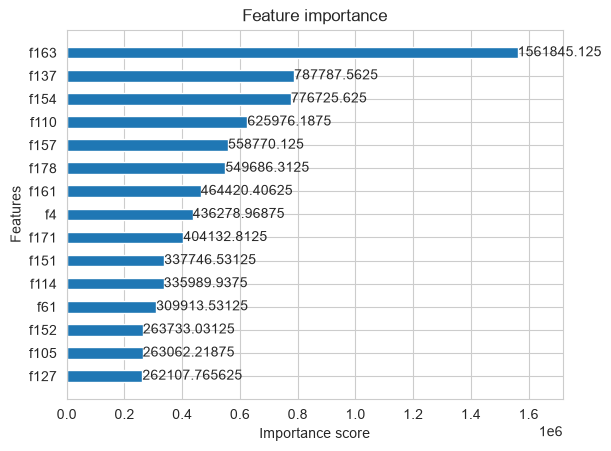

In [48]:
xgb.plot_importance(
    xgb_model,
    max_num_features=15,
    importance_type="gain",
    height=0.5
)

plt.show()

In [49]:
results = pd.DataFrame({"Model": ["Linear Regression","XGBoost Regressor"],
    "MAE": [mae,mae_xgb],
    "RMSE": [rmse,rmse_xgb],
    "R2": [r2,r2_xgb]
})
results

,Model,MAE,RMSE,R2
0,Linear Regression,67.436632,102.074349,0.057477
1,XGBoost Regressor,39.540929,69.418559,0.564077
